In [28]:
# CELL 1: Essential Imports

import sys
import os

# Must be set BEFORE importing torch or matplotlib — prevents the OMP Error #15
# kernel crash we hit earlier (duplicate OpenMP runtime)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import importlib

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    top_k_accuracy_score
)
from sklearn.preprocessing import label_binarize

# PROJECT_ROOT = r'C:\Users\aliyu\Desktop\architectural-inductive-bias-study'
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Dynamic config loading (EDIT THIS LINE ONLY)
CONFIG_MODULE = 'configs.flower_cnn'  #configs/ model name
config_module = importlib.import_module(CONFIG_MODULE)
CONFIG = config_module.CONFIG

from core_modules.model import build_model
from core_modules.dataloader import get_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")

print("✓ CONFIG loaded:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

✓ Using device: cuda
✓ CONFIG loaded:
  dataset: flowers
  model_name: cnn
  num_classes: 5
  batch_size: 64
  epochs: 40
  lr: 0.001
  input_size: 128
  device: cuda
  project_root: C:\Users\aliyu\Desktop\autodl-fs
  train_dir: C:\Users\aliyu\Desktop\autodl-fs\datasets/flowers/train
  val_dir: C:\Users\aliyu\Desktop\autodl-fs\datasets/flowers/val
  test_dir: C:\Users\aliyu\Desktop\autodl-fs\datasets/flowers/test
  phase1_augmentation: light
  weight_decay: 0.0005
  dropout_rate: 0.3
  adam_beta1: 0.9
  adam_beta2: 0.999
  adam_eps: 1e-08
  label_smoothing: 0.1
  early_stopping_patience: 6


In [29]:
# CELL 2: Load Test Dataloader

batch_size = CONFIG['batch_size']
test_dir = CONFIG['test_dir']

# Only load test — train/val not needed for final evaluation
_, _, test_loader, class_names = get_dataloaders(
    test_dir=test_dir,
    batch_size=batch_size,
    augmentation='none'
)

num_classes = len(class_names)
print(f"✓ Loaded {num_classes} test classes.")
assert CONFIG['num_classes'] == num_classes, "Mismatch: CONFIG['num_classes'] != number of classes in dataset"

✓ Loaded 5 test classes.


In [30]:
# ============================================================
# CELL 3: Load Trained Model (Best Phase 1 Model)
# ============================================================

# Path to best model — single-phase training, so this is 'trained_model.pth',
# not 'trained_model_finetune.pth' (that filename was for EfficientNet's
# phase-2 fine-tuning stage, which doesn't apply here since you're only
# running phase 1)
model_path = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'models', 'trained_model.pth')

# build_model() with checkpoint_path handles loading internally — including
# unwrapping the {'state_dict': ..., 'class_names': ..., 'config': ...} format
# your training loop saves — so no need to manually torch.load() here
model = build_model(
    device=CONFIG['device'],
    config=CONFIG,
    checkpoint_path=model_path
)
model.eval()

print("✓ Best model loaded and ready for evaluation.")

Model: CNN
Model Configuration:
├── Trainable params: 28,357
├── Frozen params: 0
└── Output head: Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=64, out_features=128, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=5, bias=True)
)

✓ Best model loaded and ready for evaluation.


In [31]:
# CELL 4: Collect Predictions

y_true = []
y_pred = []
y_probs = []

# Loop through test data — final evaluation uses the held-out test set,
# not validation (val was already used during training for early stopping)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)

        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(torch.argmax(probabilities, dim=1).cpu().numpy())
        y_probs.extend(probabilities.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

print(f"✓ Collected predictions for {len(y_true)} samples.")
print(f"Pred shape: {y_pred.shape}, Prob shape: {y_probs.shape}")

# CELL X: Setup Output Folders (Generalized for All Models)

plot_types = ['confusion_matrix', 'roc_curve', 'pr_curve', 'tsne', 'tables']
base_plot_dir = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'plots')

os.makedirs(base_plot_dir, exist_ok=True)

for subfolder in plot_types:
    subdir = os.path.join(base_plot_dir, subfolder)
    os.makedirs(subdir, exist_ok=True)

print(f"✓ Output folders ready under: {base_plot_dir}")

✓ Collected predictions for 415 samples.
Pred shape: (415,), Prob shape: (415, 5)
✓ Output folders ready under: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\cnn\plots


In [32]:
# CELL 5: Compute + Display + Save Evaluation Metrics

import pandas as pd
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)
from sklearn.preprocessing import label_binarize

# Compute metrics — Top-5 Accuracy removed: with only 5 classes, it is
# mathematically always 100% (every class is trivially in the "top 5"),
# so it carries no information here. Replaced with macro Precision/Recall,
# which are meaningful regardless of class count and pair naturally with
# your existing Macro F1.
top1_acc = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
macro_auc = roc_auc_score(y_true_bin, y_probs, average='macro', multi_class='ovr')

# Build metrics table
metrics_table = pd.DataFrame({
    'Metric': ['Top-1 Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1 Score', 'Macro AUC'],
    'Value (%)': [top1_acc * 100, macro_precision * 100, macro_recall * 100, macro_f1 * 100, macro_auc * 100]
})

for i, row in metrics_table.iterrows():
    print(f"{row['Metric']}: {row['Value (%)']:.2f}%")

tables_dir = os.path.join(base_plot_dir, 'tables')
os.makedirs(tables_dir, exist_ok=True)

metrics_csv_path = os.path.join(tables_dir, 'overall_metrics.csv')
metrics_table.to_csv(metrics_csv_path, index=False)

metrics_table

Top-1 Accuracy: 68.67%
Macro Precision: 68.84%
Macro Recall: 68.33%
Macro F1 Score: 67.99%
Macro AUC: 91.28%


,Metric,Value (%)
0,Top-1 Accuracy,68.674699
1,Macro Precision,68.841284
2,Macro Recall,68.325619
3,Macro F1 Score,67.987701
4,Macro AUC,91.281190


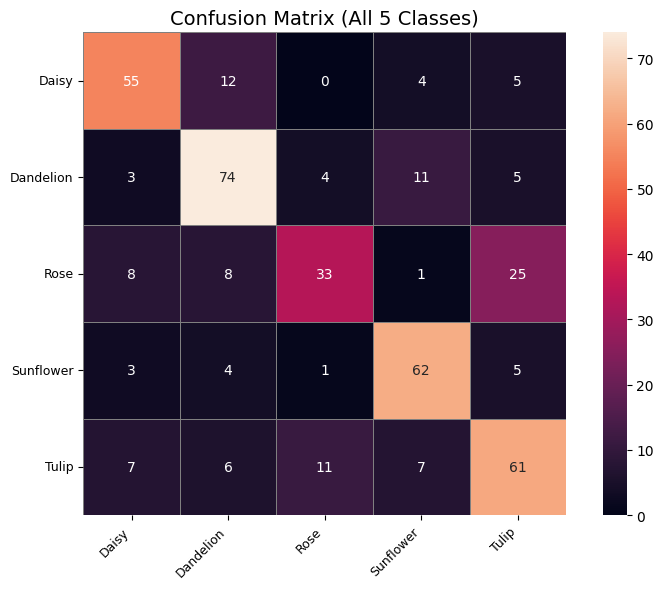

✓ Saved: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\cnn\plots\confusion_matrix\confusion_matrix_full.png


In [33]:
# CELL 6: Final Confusion Matrix

import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

confusion_dir = os.path.join(base_plot_dir, 'confusion_matrix')
os.makedirs(confusion_dir, exist_ok=True)

cm = confusion_matrix(y_true, y_pred)

def format_class_name(name):
    name = re.sub(r'^\d+[.-]', '', name)
    name = name.replace('_', ' ')
    return name.title()

formatted_class_names = [format_class_name(cname) for cname in class_names]

def plot_confusion(selected_classes, title, save_name):
    cm_subset = cm[np.ix_(selected_classes, selected_classes)]
    selected_labels = [formatted_class_names[idx] for idx in selected_classes]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_subset,
        annot=True,
        fmt='d',
        cmap='rocket',
        xticklabels=selected_labels,
        yticklabels=selected_labels,
        linewidths=0.5,
        linecolor='gray',
        cbar=True,
        square=True
    )
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()

    save_path = os.path.join(confusion_dir, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"✓ Saved: {save_path}")

# With only 5 classes, show the full confusion matrix directly —
# no need for "random 10" / "most confused 10" subsetting, which was
# designed for CUB's 200-class case
plot_confusion(
    selected_classes=list(range(cm.shape[0])),
    title="Confusion Matrix (All 5 Classes)",
    save_name="confusion_matrix_full.png"
)

In [34]:
# CELL 7: Classification Report for 10 Random Classes


from sklearn.metrics import classification_report
import pandas as pd
import re
import os

# Format class names (reusable)
def format_class_name(name):
    name = re.sub(r'^\d+[.-]', '', name)
    name = name.replace('_', ' ')
    return name.title()

formatted_class_names = [format_class_name(cname) for cname in class_names]

# Handle case where number of classes < 10
if len(formatted_class_names) < 10:
    random_classes = list(range(len(formatted_class_names)))
else:
    random_classes = random.sample(range(len(formatted_class_names)), 10)

# Step 1: Full classification report
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=formatted_class_names,
    output_dict=True,
    zero_division=0
)

# Step 2: Extract only the selected class subset
selected_labels = [formatted_class_names[idx] for idx in random_classes]
selected_report = {
    label: report_dict[label] for label in selected_labels if label in report_dict
}

# Step 3: Convert to DataFrame
df_report = pd.DataFrame(selected_report).transpose()
df_report = df_report[['precision', 'recall', 'f1-score', 'support']]
df_report = df_report.round(4)

# tep 4: Display in notebook
print("\n📋 Classification Report for the 5 Classes:")
display(df_report)

# Step 5: Save to CSV (ensure table directory exists)
tables_dir = os.path.join(base_plot_dir, 'tables')
os.makedirs(tables_dir, exist_ok=True)

report_csv_path = os.path.join(tables_dir, 'precision recall for the 5 classes.csv')
df_report.to_csv(report_csv_path, index=True)

print(f"✓ Report saved to: {report_csv_path}")



📋 Classification Report for the 5 Classes:


,precision,recall,f1-score,support
Daisy,0.7237,0.7237,0.7237,76.0
Dandelion,0.7115,0.7629,0.7363,97.0
Rose,0.6735,0.4400,0.5323,75.0
Sunflower,0.7294,0.8267,0.7750,75.0
Tulip,0.6040,0.6630,0.6321,92.0


✓ Report saved to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\cnn\plots\tables\precision recall for the 5 classes.csv


In [35]:
# CELL 8: Classification Report (All Classes)


from sklearn.metrics import classification_report
import pandas as pd
import re
import os

def format_class_name(name):
    name = re.sub(r'^\d+[.-]', '', name)
    name = name.replace('_', ' ')
    return name.title()

formatted_class_names = [format_class_name(cname) for cname in class_names]

# Full classification report — with only 5 classes, no subsetting needed,
# this already shows everything the "10 most confused" version would have
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=formatted_class_names,
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report[['precision', 'recall', 'f1-score', 'support']].round(4)

print("\n📋 Classification Report (All 5 Classes):")
display(df_report)

tables_dir = os.path.join(base_plot_dir, 'tables')
os.makedirs(tables_dir, exist_ok=True)

report_path = os.path.join(tables_dir, 'precision_recall_all_classes.csv')
df_report.to_csv(report_path, index=True)

print(f"✓ Report saved to: {report_path}")


📋 Classification Report (All 5 Classes):


,precision,recall,f1-score,support
Daisy,0.7237,0.7237,0.7237,76.0000
Dandelion,0.7115,0.7629,0.7363,97.0000
Rose,0.6735,0.4400,0.5323,75.0000
Sunflower,0.7294,0.8267,0.7750,75.0000
Tulip,0.6040,0.6630,0.6321,92.0000
accuracy,0.6867,0.6867,0.6867,0.6867
macro avg,0.6884,0.6833,0.6799,415.0000
weighted avg,0.6863,0.6867,0.6810,415.0000


✓ Report saved to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\cnn\plots\tables\precision_recall_all_classes.csv


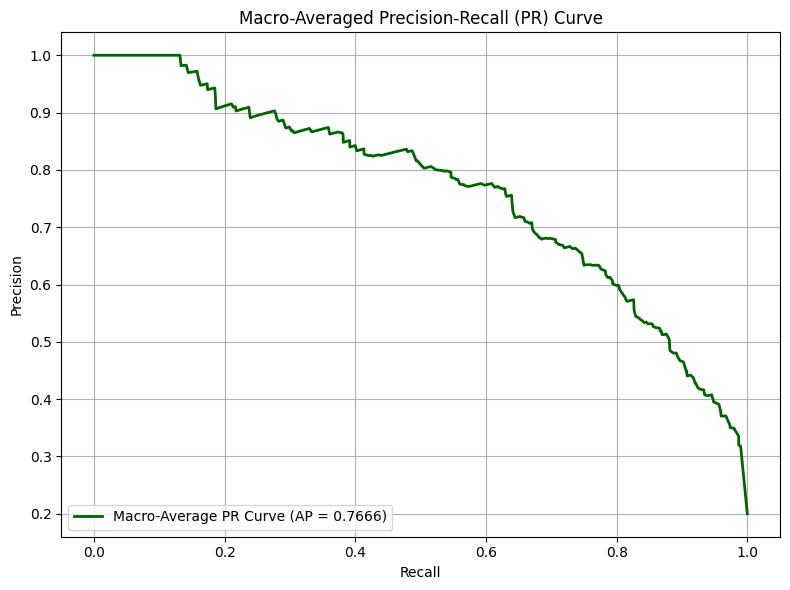

✓ Saved macro-average PR curve to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\cnn\plots\pr_curve\macro_pr_curve.png


In [36]:
# CELL 9: Plot Macro-Averaged Precision-Recall (PR) Curve

from sklearn.metrics import precision_recall_curve, average_precision_score
import os

# Step 1: Binarize ground truth
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Step 2: Compute per-class PR and AP
precision, recall, average_precision = {}, {}, {}

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], y_probs[:, i])

# Step 3: Macro-averaged precision-recall
all_recall = np.unique(np.concatenate([recall[i] for i in range(num_classes)]))
mean_precision = np.zeros_like(all_recall)

for i in range(num_classes):
    mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])  # Reverse for increasing recall

mean_precision /= num_classes
macro_avg_precision = np.mean(list(average_precision.values()))

# Step 4: Plot
plt.figure(figsize=(8, 6))
plt.plot(all_recall, mean_precision, color='darkgreen', lw=2,
         label=f"Macro-Average PR Curve (AP = {macro_avg_precision:.4f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-Averaged Precision-Recall (PR) Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()

# Save modularly to pr_curve/
pr_curve_dir = os.path.join(base_plot_dir, 'pr_curve')
os.makedirs(pr_curve_dir, exist_ok=True)

pr_path = os.path.join(pr_curve_dir, 'macro_pr_curve.png')
plt.savefig(pr_path, dpi=300)
plt.show()
plt.close()

print(f"✓ Saved macro-average PR curve to: {pr_path}")


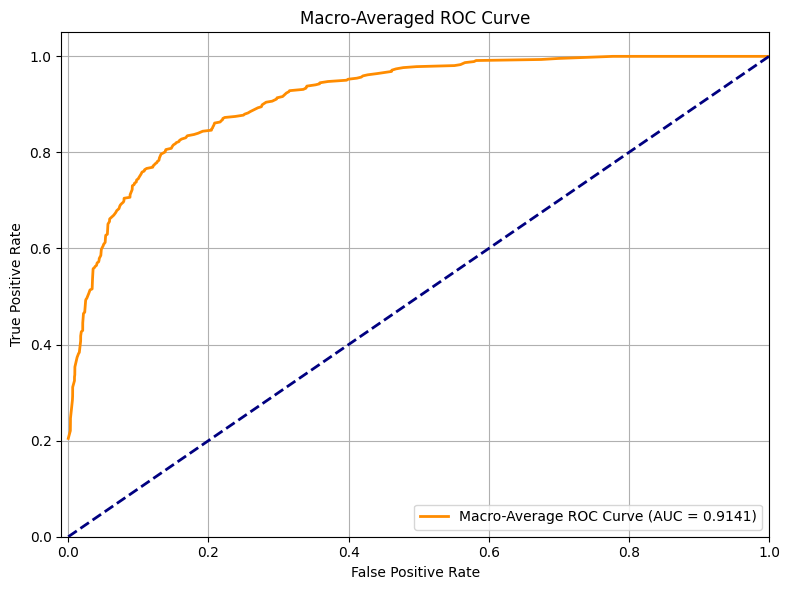

✓ Saved macro-average ROC curve to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\cnn\plots\roc_curve\macro_roc_curve.png


In [37]:
# CELL 10: Plot Macro-Averaged ROC Curve

from sklearn.metrics import roc_curve, auc
import os

# Step 1: Binarize ground truth
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Step 2: Compute per-class ROC and AUC
fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 3: Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
macro_roc_auc = auc(all_fpr, mean_tpr)

# Step 4: Plot
plt.figure(figsize=(8, 6))
plt.plot(all_fpr, mean_tpr, color='darkorange', lw=2,
         label=f"Macro-Average ROC Curve (AUC = {macro_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random baseline
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Averaged ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

# Save using modular CONFIG path
roc_dir = os.path.join(base_plot_dir, 'roc_curve')
os.makedirs(roc_dir, exist_ok=True)
roc_path = os.path.join(roc_dir, 'macro_roc_curve.png')
plt.savefig(roc_path, dpi=300)
plt.show()
plt.close()

print(f"✓ Saved macro-average ROC curve to: {roc_path}")


In [38]:
# CELL 10: Collect Best Correct & Most Confused Predictions

import torch
import numpy as np
from collections import defaultdict

CONFIDENCE_THRESHOLD = 0.9
MAX_CONFIDENT = 5
MAX_CONFUSED = 5

best_correct = {}
fallback_correct = defaultdict(lambda: (None, -1.0))
most_confused = {}

# Loop through test set — final evaluation uses held-out test data
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        for i in range(len(labels)):
            true_label = labels[i].item()
            pred_label = preds[i].item()
            confidence = probs[i][pred_label].item()

            if pred_label == true_label:
                if confidence >= CONFIDENCE_THRESHOLD and true_label not in best_correct:
                    best_correct[true_label] = (inputs[i].cpu(), true_label, confidence)
                if confidence > fallback_correct[true_label][1]:
                    fallback_correct[true_label] = (inputs[i].cpu(), confidence)

            elif confidence >= CONFIDENCE_THRESHOLD and true_label not in most_confused:
                most_confused[true_label] = (inputs[i].cpu(), pred_label, confidence)

for cls, (img_tensor, conf) in fallback_correct.items():
    if cls not in best_correct:
        best_correct[cls] = (img_tensor, cls, conf)
    if len(best_correct) >= MAX_CONFIDENT:
        break

correct_images = [v[0] for v in list(best_correct.values())[:MAX_CONFIDENT]]
correct_labels = [v[1] for v in list(best_correct.values())[:MAX_CONFIDENT]]
confidences = [v[2] for v in list(best_correct.values())[:MAX_CONFIDENT]]

confused_images = [v[0] for v in list(most_confused.values())[:MAX_CONFUSED]]
confused_labels = [v[1] for v in list(most_confused.values())[:MAX_CONFUSED]]

print(f"✓ Collected {len(correct_images)} confident correct and {len(confused_images)} confused predictions.")

✓ Collected 5 confident correct and 0 confused predictions.


✓ Processed sample 1/5
✓ Processed sample 2/5
✓ Processed sample 3/5
✓ Processed sample 4/5
✓ Processed sample 5/5


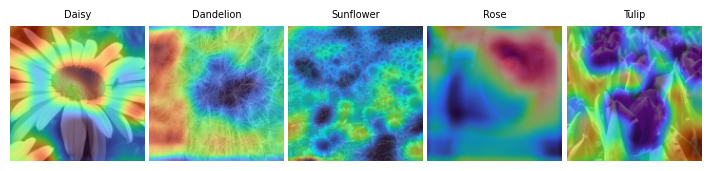

✓ Occlusion heatmap grid saved to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\cnn\plots\occlusion\occlusion_top5_compact.png


In [39]:
# CELL 11: Occlusion Heatmap Grid for Top-5 Confident Correct Samples
# (High-resolution version — fine stride for maximum smoothness/detail)

import matplotlib.pyplot as plt
import re
import numpy as np
import cv2
import torch
import torchvision.transforms as transforms
from torchvision.transforms.functional import to_pil_image
import os

unnormalize = transforms.Normalize(
    mean=[-m / s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1 / s for s in [0.229, 0.224, 0.225]]
)

def format_class_name(name):
    name = re.sub(r'^\d+[.-]?', '', name)
    name = name.replace('_', ' ').replace('-', ' ')
    return name.title()

def compute_occlusion(model, img_tensor, target_class, patch_size=16, stride=2, occlusion_value=0.0):
    """
    Occlusion sensitivity: slides a patch across the image, masking it out
    at each position, and measures the drop in the target class's predicted
    probability. Fine stride (2px) relative to patch_size (16px) means
    heavy overlap between tested positions, producing a smooth, detailed
    heatmap rather than a blocky one.
    """
    model.eval()
    img_tensor = img_tensor.clone().unsqueeze(0).to(device)
    _, channels, height, width = img_tensor.shape

    with torch.no_grad():
        baseline_output = model(img_tensor)
        baseline_prob = torch.nn.functional.softmax(baseline_output, dim=1)[0, target_class].item()

    heatmap = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros((height, width), dtype=np.float32)

    with torch.no_grad():
        for y in range(0, height - patch_size + 1, stride):
            for x in range(0, width - patch_size + 1, stride):
                occluded = img_tensor.clone()
                occluded[:, :, y:y+patch_size, x:x+patch_size] = occlusion_value

                output = model(occluded)
                prob = torch.nn.functional.softmax(output, dim=1)[0, target_class].item()

                drop = baseline_prob - prob
                heatmap[y:y+patch_size, x:x+patch_size] += drop
                counts[y:y+patch_size, x:x+patch_size] += 1

    counts[counts == 0] = 1
    heatmap /= counts

    heatmap = np.clip(heatmap, 0, None)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # Extra Gaussian smoothing pass for a cleaner, more polished look —
    # purely cosmetic, doesn't change which regions are highlighted
    heatmap = cv2.GaussianBlur(heatmap, (9, 9), sigmaX=2)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    return heatmap

display_size = CONFIG.get('input_size', 128)

occlusion_images = []
titles = []

for idx in range(len(correct_images)):
    try:
        img_tensor = correct_images[idx]
        target_class = correct_labels[idx]

        occlusion_map = compute_occlusion(model, img_tensor, target_class)
        heatmap = cv2.applyColorMap(np.uint8(255 * occlusion_map), cv2.COLORMAP_TURBO)

        img = unnormalize(img_tensor).clamp(0, 1)
        img_np = np.array(to_pil_image(img))
        overlay = cv2.addWeighted(img_np.astype(np.float32) / 255, 0.35,
                                  heatmap.astype(np.float32) / 255, 0.65, 0)
        occlusion_images.append(np.uint8(overlay * 255))
        titles.append(format_class_name(class_names[correct_labels[idx]]))
        print(f"✓ Processed sample {idx+1}/{len(correct_images)}")
    except Exception as e:
        print(f"⚠️ Occlusion heatmap failed on sample {idx}: {e}")

base_plot_dir = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'plots')
occlusion_dir = os.path.join(base_plot_dir, 'occlusion')
os.makedirs(occlusion_dir, exist_ok=True)
save_path = os.path.join(occlusion_dir, 'occlusion_top5_compact.png')

fig, axs = plt.subplots(1, len(occlusion_images), figsize=(1.4 * len(occlusion_images), 1.6))
for i, ax in enumerate(axs):
    ax.imshow(cv2.cvtColor(occlusion_images[i], cv2.COLOR_BGR2RGB))
    ax.set_title(titles[i], fontsize=7)
    ax.axis('off')

plt.tight_layout(pad=0.3)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✓ Occlusion heatmap grid saved to: {save_path}")

✓ Using all 5 classes (415 total samples)


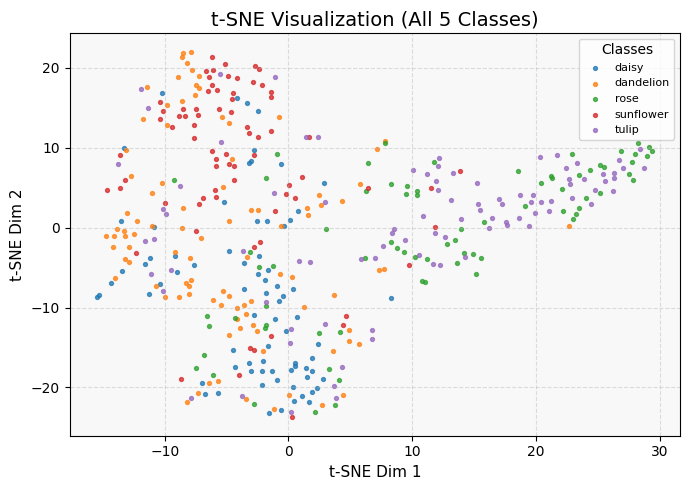

✓ t-SNE plot saved to: C:\Users\aliyu\Desktop\autodl-fs\experiments\flowers\cnn\plots\tsne\tsne_5classes.png


In [40]:
# CELL 12: t-SNE Visualization (All 5 Classes)

from sklearn.manifold import TSNE
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Step 1: Extract features from test set
features = []
labels_list = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        # Feature extraction logic per model type
        if CONFIG['model_name'] == 'cnn':
            # self.features already ends in AdaptiveAvgPool2d(1) in our CNN,
            # so this gives the pooled feature vector directly —
            # the same representation that feeds into the classifier head
            feats = model.features(inputs)
            feats = torch.flatten(feats, 1)

        elif CONFIG['model_name'] == 'rnn':
            # Same row-as-timestep reshaping used in rnn.py's forward() —
            # must match exactly, since we're manually replicating the first
            # part of the forward pass here to grab the hidden state before
            # it reaches the classifier head
            batch_size, channels, height, width = inputs.shape
            x = inputs.permute(0, 2, 1, 3)
            x = x.reshape(batch_size, height, channels * width)

            with torch.backends.cudnn.flags(enabled=False):
                if model.rnn_type == 'lstm':
                    _, (hidden, _) = model.rnn(x)
                else:
                    _, hidden = model.rnn(x)

            feats = hidden[-1]  # (B, hidden_size) — final layer's hidden state

        elif CONFIG['model_name'] == 'mlp':
            # MLP has no separate self.features — self.classifier is one continuous
            # block. Run through everything except the final Linear(hidden, num_classes)
            # layer, to get the last hidden representation before classification.
            x = inputs
            for layer in model.classifier[:-1]:
                x = layer(x)
            feats = x

        else:
            raise ValueError(f"t-SNE feature extraction not supported for model: {CONFIG['model_name']}")
                
        features.append(feats.cpu().numpy())
        labels_list.append(labels.cpu().numpy())

# Step 2: Concatenate — use ALL classes, since we only have 5 total
# (no need to subsample down to 10, unlike the CUB 200-class case)
features = np.concatenate(features, axis=0)
labels_list = np.concatenate(labels_list, axis=0)

unique_classes = np.unique(labels_list)
num_plot_classes = len(unique_classes)

print(f"✓ Using all {num_plot_classes} classes ({features.shape[0]} total samples)")

# Step 3: Relabel for visual clarity
label_encoder = LabelEncoder()
numeric_labels = label_encoder.fit_transform(labels_list)
class_names_display = [class_names[c] for c in label_encoder.classes_]

# Step 4: Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
features_2d = tsne.fit_transform(features)

# Step 5: Plot
plt.figure(figsize=(7, 5))
palette = sns.color_palette("tab10")[:num_plot_classes]

for i in range(num_plot_classes):
    idx = (numeric_labels == i)
    plt.scatter(
        features_2d[idx, 0], features_2d[idx, 1],
        s=8, alpha=0.75, color=palette[i], label=class_names_display[i]
    )

plt.title("t-SNE Visualization (All 5 Classes)", fontsize=14)
plt.xlabel("t-SNE Dim 1", fontsize=11)
plt.ylabel("t-SNE Dim 2", fontsize=11)
plt.legend(title="Classes", loc="best", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_facecolor('#f8f8f8')
plt.tight_layout()

# Step 6: Save plot
tsne_dir = os.path.join(CONFIG['project_root'], 'experiments', CONFIG['dataset'], CONFIG['model_name'], 'plots', 'tsne')
os.makedirs(tsne_dir, exist_ok=True)
tsne_path = os.path.join(tsne_dir, 'tsne_5classes.png')
plt.savefig(tsne_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ t-SNE plot saved to: {tsne_path}")